→ Preparing splits for: 'Eurasian Otter.csv' (species key = 'Eurasian Otter')
[REPORT] cleaned Aj_Someringii: shape=(370, 141)
[WARN] plotting failed for Aj_Someringii: cannot import name 'plot_feature_distributions' from 'FIT_python.general_pipeline_steps.outlier_wrapper' (C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\general_pipeline_steps\outlier_wrapper.py)
[REPORT] cleaned Amur_Tiger: shape=(605, 133)
[WARN] plotting failed for Amur_Tiger: cannot import name 'plot_feature_distributions' from 'FIT_python.general_pipeline_steps.outlier_wrapper' (C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\general_pipeline_steps\outlier_wrapper.py)
[REPORT] cleaned Bengal_tiger: shape=(586, 133)
[WARN] plotting failed for Bengal_tiger: cannot import name 'plot_feature_distributions' from 'FIT_python.general_pipeline_steps.outlier_wrapper' (C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\general_pipeline_steps

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\data_split_and_summary\split_utils.py:216: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df["fold"] = folds


Fold distribution (train):
 fold
0    196
1    196
2    196
Name: count, dtype: int64
   ✔ wrote C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\data\splits\eurasian_otter\train.parquet
   ✔ wrote C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\data\splits\eurasian_otter\test.parquet
   ✔ wrote C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\data\splits\eurasian_otter\inference.parquet

[DEBUG] compute_summary called for eurasian_otter/inference, df shape = (0, 214)
[DEBUG] df is empty, returning empty summary

[DEBUG] compute_summary called for eurasian_otter/test, df shape = (40, 214)
[DEBUG] ds_label = eurasian_otter Test
[DEBUG] species column raw: species exists? True, Species exists? False
[DEBUG] using 'species' column
[DEBUG] species_vals = ['lutra_lutra']
[DEBUG] species_code = lutra lutra
[DEBUG] sex value counts:
sex
F    25
M    15
Name: count, dtype: int64
[DEBUG] sex = F, subset shape = (25, 214)
[DEBUG]  n_fp=25, n_ind=2, n_tr=4


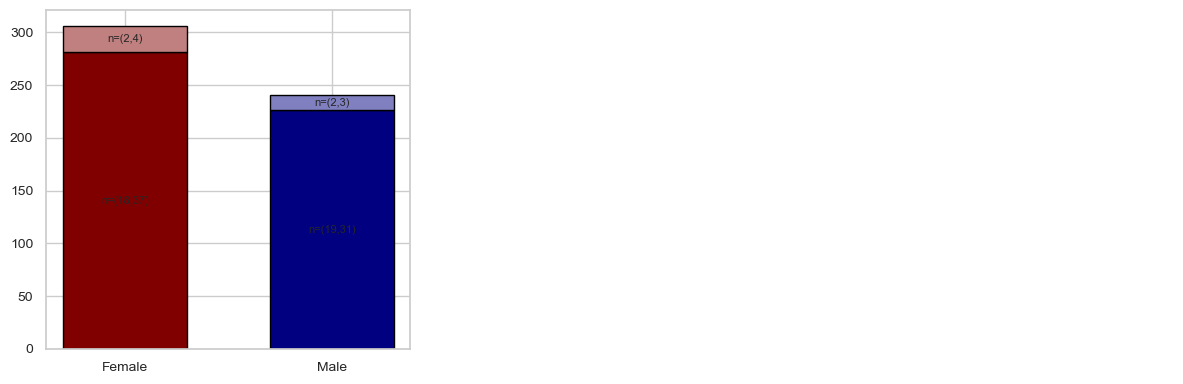

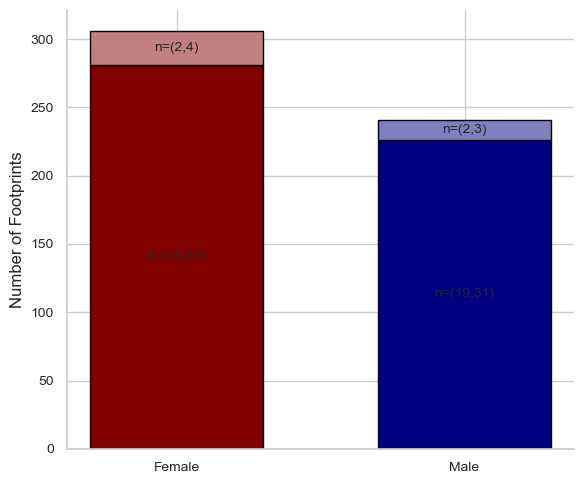

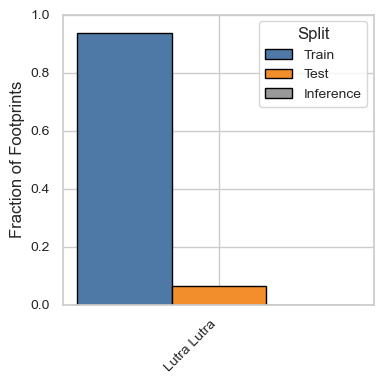

In [2]:
from FIT_python.data_split_and_summary.datasplit_and_summary_wraper import prepare_all_splits
from pathlib import Path

csv_path = Path("data/raw/Eurasian Otter.csv")
prepare_all_splits(csv_path)


In [2]:
from FIT_python.plot_style import apply_style
apply_style()
import pandas as pd
from pathlib import Path
from FIT_python.pipeline_individual_id.utils import sequential_holdout_ids
from FIT_python.pipeline_individual_id.geometric_pairwise_projection import generate_pairwise_comparisons_from_df
from FIT_python.pipeline_individual_id.baseline_pipeline import DistanceBaseline
from FIT_python.pipeline_individual_id.supervised_umap_pipeline import run as run_umap
#from FIT_python.pipeline_individual_id.siamese_pipeline import run as run_siamese
from FIT_python.pipeline_individual_id.evaluation import compute_confusion
import seaborn as sns, matplotlib.pyplot as plt
from FIT_python.data_split_and_summary.data_import_utils import load_and_prep_df_individual, get_feature_cols
from FIT_python.config import RESULTS_DATA_DIR, SPLITS_DIR


# %% 1) Basis-Pfade & Hyperparameter-Räume (unverändert)
splits_root = Path("data/splits/eurasian_otter")
models_root = RESULTS_DATA_DIR / "eurasian_otter_random_search_standard_metrics" / "best_maj_test_pct"
output_root = Path("results/data/pairwise_comp_eurasian_otter")
output_root.mkdir(parents=True, exist_ok=True)

# 6) Loop über Spezies
species_dir = Path(SPLITS_DIR)/"eurasian_otter"
species = "eurasian_otter"
print(f"\n🔄 Processing species: {species}")

# 6.1) Train/Test laden & Fold entfernen
df = load_and_prep_df_individual(species, Path(SPLITS_DIR)) #falls hier bugs valid vales f und m checken

feature_cols = [c for c in df.columns if c.startswith(('dist','ang','t','v')) and c!='trail']
ids = df['individual_id'].unique()
split = sequential_holdout_ids(ids, val_sizes=[3,5,9], n_iter=1, random_state=0)[0]
train_df = df[df['individual_id'].isin(split['train_ids'])]
val_df = df[df['individual_id'].isin(split['val_ids'])]
val_comps = generate_pairwise_comparisons_from_df(
    val_df,
    id_col="individual_id",
    group_sizes=[3,5,7,10],
    n_repeats=2,
    mode="both",
    selfmatch_factor=2.0,
    n_folds=5,
    random_state=42,
    show_progress=True
)

# In ein DataFrame überführen
df_val_comps = pd.DataFrame(val_comps)


c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\tqdm_joblib\__init__.py:4: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm



🔄 Processing species: eurasian_otter


ValueError: n_splits=5 cannot be greater than the number of members in each class.

In [ ]:
val_comps

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from FIT_python.pipeline_individual_id.baseline_pipeline import DistanceBaseline
from FIT_python.pipeline_individual_id.evaluation import compute_confusion

# 1) Generiere die Features & Labels
res_base = DistanceBaseline.run(train_df, val_comps, feature_cols)
Xb       = res_base.filter(regex='^dist_')
yb       = res_base['same_individual'].map({'True': 1, 'False': 0})

# 2) Definiere Stratified 5-Fold CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr = LogisticRegression(max_iter=200)

# 3) Erzeuge CV-Predictions für jedes Sample im Validation-Set
y_pred = cross_val_predict(lr, Xb, yb, cv=cv)

# 4) Berechne die Konfusionsmatrix
cm_base = compute_confusion(pd.DataFrame({'same_individual': yb, 'pred': y_pred}))

# 5) Visualisiere
plt.figure(figsize=(6, 5))
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('5-Fold Stratified CV Confusion Matrix')
plt.show()



In [ ]:
res_umap, emb_umap = run_umap(train_df, val_comps, feature_cols)
yu = res_umap['same_individual'].map({'True':1,'False':0})
pred_u = (res_umap['pred_same_proba']>0.5).astype(int)
cm_umap = compute_confusion(pd.DataFrame({'same_individual':yu,'pred':pred_u}))
sns.heatmap(cm_umap, annot=True, fmt='d'); plt.show()


In [ ]:
res_siam = run_siamese(train_df, val_comps, feature_cols)
ys = pd.Series([c['same_individual'] for c in val_comps]).map({'True':1,'False':0})
pred_s = (pd.Series([r['pred_same'] for r in res_siam])>0.5).astype(int)
cm_siam = compute_confusion(pd.DataFrame({'same_individual':ys,'pred':pred_s}))
sns.heatmap(cm_siam, annot=True, fmt='d'); plt.show()
